# Data Analysis Cycle

##  Question & Goal
**Core Objective:** Solve the annual wheat deficit problem in Pakistan.



### Important Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


Agri_data=pd.read_csv('/kaggle/input/datasets/azharalisoomro/pakistan-agricultural-20002024-faostat-data/FAOSTAT_data_en_6-17-2026.csv')
Popu_data=pd.read_csv('/kaggle/input/datasets/azharalisoomro/world-population-dataset/API_SP.POP.TOTL_DS2_en_csv_v2_406129.csv')


## STEP 1: Filter and Prepare the Population Data

In [2]:
# Filter specifically for Pakistan
pak_pop = Popu_data[Popu_data['Country Name'] == 'Pakistan']

# Select only the year columns we care about (2000 to 2024)
year_columns = [str(year) for year in range(2000, 2025)]
pak_pop_years = pak_pop[year_columns]
#print(pak_pop_years)

# Melt the horizontal years into a vertical layout (Year and Population columns)
pak_pop_vertical = pak_pop_years.melt(var_name='Year', value_name='Population')

# Convert 'Year' column to integer so it matches the agriculture dataset type
pak_pop_vertical['Year'] = pak_pop_vertical['Year'].astype(int)
print(pak_pop_vertical)

    Year   Population
0   2000  154879127.0
1   2001  159270907.0
2   2002  163222549.0
3   2003  167110248.0
4   2004  171286000.0
5   2005  175453212.0
6   2006  179682690.0
7   2007  184493231.0
8   2008  189499113.0
9   2009  194376534.0
10  2010  199239047.0
11  2011  203746065.0
12  2012  207667125.0
13  2013  211073978.0
14  2014  214264647.0
15  2015  217290883.0
16  2016  220138869.0
17  2017  223273967.0
18  2018  226928892.0
19  2019  230800899.0
20  2020  235001746.0
21  2021  239477801.0
22  2022  243700667.0
23  2023  247504495.0
24  2024  251269164.0


## STEP 2: Filter and Pivot the Agricultural Data

In [3]:

# Filter for Wheat only
wheat_data = Agri_data[Agri_data['Item'] == 'Wheat']

# Pivot the data so 'Area harvested', 'Yield', and 'Production' get their own individual columns
wheat_pivoted = wheat_data.pivot(index='Year', columns='Element', values='Value').reset_index()

# Clean up column names for readability
wheat_pivoted.columns.name = None  # Remove metadata label
wheat_pivoted = wheat_pivoted.rename(columns={
    'Area harvested': 'Area_Harvested_ha',
    'Yield': 'Yield_kg_ha',
    'Production': 'Production_tonnes'
})
print(wheat_pivoted)

    Year  Area_Harvested_ha  Production_tonnes  Yield_kg_ha
0   2000          8463000.0         21078600.0       2490.7
1   2001          8180800.0         19023700.0       2325.4
2   2002          8057500.0         18226500.0       2262.1
3   2003          8033900.0         19183300.0       2387.8
4   2004          8216200.0         19499800.0       2373.3
5   2005          8358000.0         21612300.0       2585.8
6   2006          8447900.0         21276900.0       2518.6
7   2007          8578000.0         23294600.0       2715.6
8   2008          8549800.0         20958800.0       2451.4
9   2009          9046000.0         24033000.0       2656.8
10  2010          9131600.0         23310800.0       2552.8
11  2011          8900700.0         25213800.0       2832.8
12  2012          8649800.0         23473400.0       2713.8
13  2013          8660077.0         24211360.0       2795.7
14  2014          9199318.0         25979399.0       2824.1
15  2015          9203874.0         2508

## STEP 3: Combine Both Datasets

In [4]:

# Merge the vertical population data with our pivoted wheat metrics on 'Year'
final_df = pd.merge(wheat_pivoted, pak_pop_vertical, on='Year')

# Display the final structured dataset
final_df.head()


,Year,Area_Harvested_ha,Production_tonnes,Yield_kg_ha,Population
0,2000,8463000.0,21078600.0,2490.7,154879127.0
1,2001,8180800.0,19023700.0,2325.4,159270907.0
2,2002,8057500.0,18226500.0,2262.1,163222549.0
3,2003,8033900.0,19183300.0,2387.8,167110248.0
4,2004,8216200.0,19499800.0,2373.3,171286000.0


## STEP 4: CALCULATING CONSUMPTION & DEFICIT
 ### Industry Standard Benchmark: Average annual wheat consumption in Pakistan 
 is approximately 125 kg per person according to the Pakistan Agricultural Research Council (PARC) 
 and the Food and Agriculture Organization (FAO).
 ### Waste and Seed Factor: We add 10% extra to account for grain reserved for 
next year's seeds, animal feed, and unavoidable post-harvest storage losses.

In [5]:


WHEAT_PER_CAPITA_KG = 125


WASTAGE_SEED_FACTOR = 1.10

# 1. Calculate Human Consumption Demand
# Divided by 1000 to convert kilograms (kg) into metric Tonnes to match the production unit
final_df['Human_Consumption_tonnes'] = (final_df['Population'] * WHEAT_PER_CAPITA_KG) / 1000

# 2. Calculate Total National Demand including the 10% seed/waste overhead
final_df['Total_Demand_Required_tonnes'] = final_df['Human_Consumption_tonnes'] * WASTAGE_SEED_FACTOR

# 3. Calculate the Deficit or Surplus (Production minus Total Demand Required)
# Negative (-) values reveal a supply deficit requiring international imports.
# Positive (+) values indicate a national crop surplus.
final_df['Deficit_Surplus_tonnes'] = final_df['Production_tonnes'] - final_df['Total_Demand_Required_tonnes']

# Display the data frame with clear column names to the viewer
print(final_df[['Year', 'Population', 'Production_tonnes', 'Total_Demand_Required_tonnes', 'Deficit_Surplus_tonnes']].head())

   Year   Population  Production_tonnes  Total_Demand_Required_tonnes  \
0  2000  154879127.0         21078600.0                  2.129588e+07   
1  2001  159270907.0         19023700.0                  2.189975e+07   
2  2002  163222549.0         18226500.0                  2.244310e+07   
3  2003  167110248.0         19183300.0                  2.297766e+07   
4  2004  171286000.0         19499800.0                  2.355183e+07   

   Deficit_Surplus_tonnes  
0           -2.172800e+05  
1           -2.876050e+06  
2           -4.216600e+06  
3           -3.794359e+06  
4           -4.052025e+06  


## STEP 5: VISUALISING THE WHEAT DEFICIT TRAJECTORY

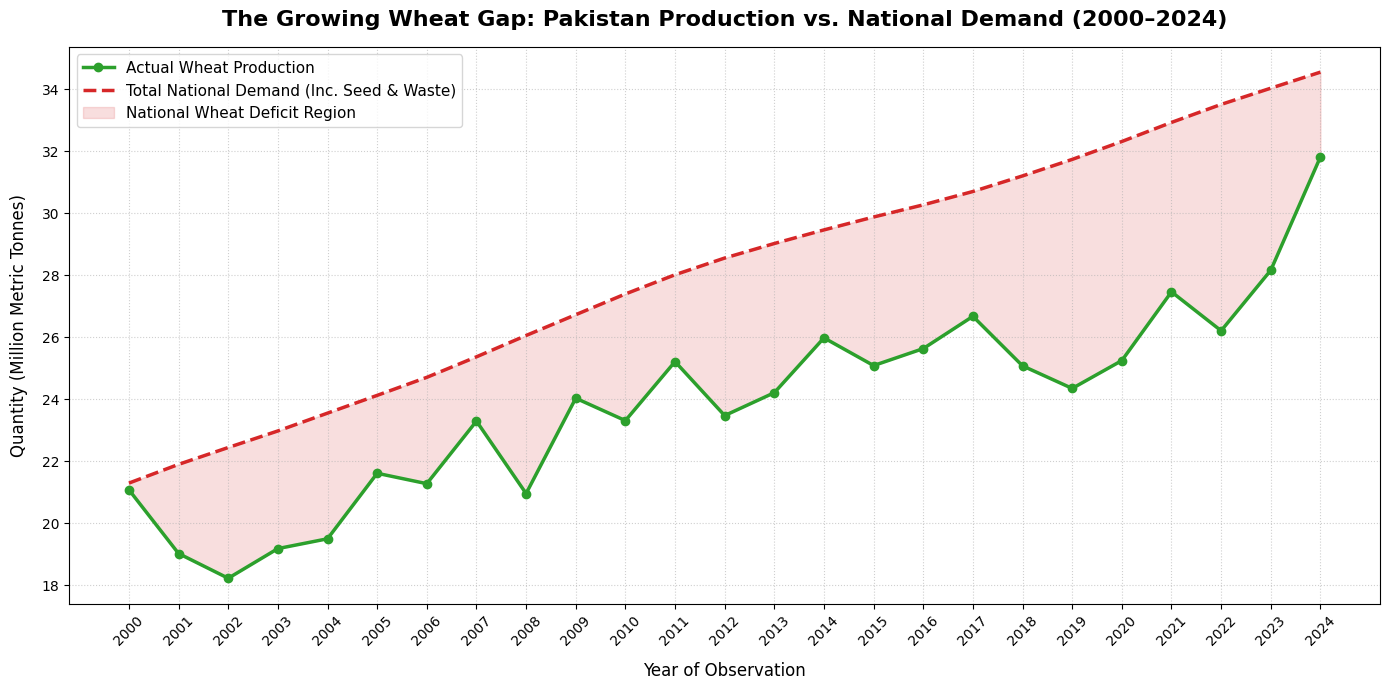

In [6]:


plt.figure(figsize=(14, 7))

# 1. Plot Actual Production (Supply)
plt.plot(final_df['Year'], final_df['Production_tonnes'] / 1e6, 
         label='Actual Wheat Production', color='#2ca02c', marker='o', linewidth=2.5)

# 2. Plot Total National Demand (Required)
plt.plot(final_df['Year'], final_df['Total_Demand_Required_tonnes'] / 1e6, 
         label='Total National Demand (Inc. Seed & Waste)', color='#d62728', linestyle='--', linewidth=2.5)

# 3. Highlight the Deficit area in light red where Demand exceeds Production
plt.fill_between(final_df['Year'], final_df['Production_tonnes'] / 1e6, final_df['Total_Demand_Required_tonnes'] / 1e6,
                 where=(final_df['Production_tonnes'] < final_df['Total_Demand_Required_tonnes']),
                 color='#d62728', alpha=0.15, label='National Wheat Deficit Region')

# 4. Chart Styling & Formatting
plt.title('The Growing Wheat Gap: Pakistan Production vs. National Demand (2000–2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year of Observation', fontsize=12, labelpad=10)
plt.ylabel('Quantity (Million Metric Tonnes)', fontsize=12, labelpad=10)
plt.xticks(final_df['Year'], rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

# Render the final chart
plt.show()

## STEP 6: STRATEGIC FORECASTING FOR 2030 (ACT)

In [7]:

# 1. Define future 2030 benchmarks based on historical growth trends
POPULATION_2030_ESTIMATED = 268000000  # Estimated 268 Million people by 2030
WHEAT_PER_CAPITA_KG = 125
WASTAGE_SEED_FACTOR = 1.10

# 2. Calculate the Total National Demand required by 2030 (in Metric Tonnes)
human_demand_2030 = (POPULATION_2030_ESTIMATED * WHEAT_PER_CAPITA_KG) / 1000
TOTAL_DEMAND_2030_TONNES = human_demand_2030 * WASTAGE_SEED_FACTOR

# 3. Get the average harvested area available for wheat from the last 5 years of your data
recent_area_ha = final_df['Area_Harvested_ha'].tail(5).mean()

# 4. Calculate the required strategic yield target to achieve 100% self-sufficiency
# Formula: Required Yield (kg/ha) = Total Target Production (kg) / Total Area (ha)
target_production_kg = TOTAL_DEMAND_2030_TONNES * 1000
REQUIRED_YIELD_2030_KG_HA = target_production_kg / recent_area_ha

# 5. Extract the latest actual yield from your dataset (2024 value) for comparison
latest_actual_yield = final_df['Yield_kg_ha'].iloc[-1]
yield_gap_increase = REQUIRED_YIELD_2030_KG_HA - latest_actual_yield

# Print the actionable policy insights
print(f"--- PAKISTAN WHEAT SELF-SUFFICIENCY TARGETS FOR 2030 ---")
print(f"Estimated 2030 Population: {POPULATION_2030_ESTIMATED / 1e6:.1f} Million")
print(f"Required Wheat Production by 2030: {TOTAL_DEMAND_2030_TONNES / 1e6:.2f} Million Tonnes")
print(f"Available Wheat Farmland Area: {recent_area_ha / 1e6:.2f} Million Hectares\n")

print(f"Latest Baseline Yield: {latest_actual_yield:.2f} kg/ha")
print(f"Required Yield Target by 2030: {REQUIRED_YIELD_2030_KG_HA:.2f} kg/ha")
print(f"Net Yield Improvement Needed: {yield_gap_increase:.2f} kg/ha ({((yield_gap_increase/latest_actual_yield)*100):.1f}% increase)")

--- PAKISTAN WHEAT SELF-SUFFICIENCY TARGETS FOR 2030 ---
Estimated 2030 Population: 268.0 Million
Required Wheat Production by 2030: 36.85 Million Tonnes
Available Wheat Farmland Area: 9.14 Million Hectares

Latest Baseline Yield: 3268.30 kg/ha
Required Yield Target by 2030: 4030.25 kg/ha
Net Yield Improvement Needed: 761.95 kg/ha (23.3% increase)


## VISUALISATION: HISTORICAL DEFICIT & SURPLUS BAR CHART

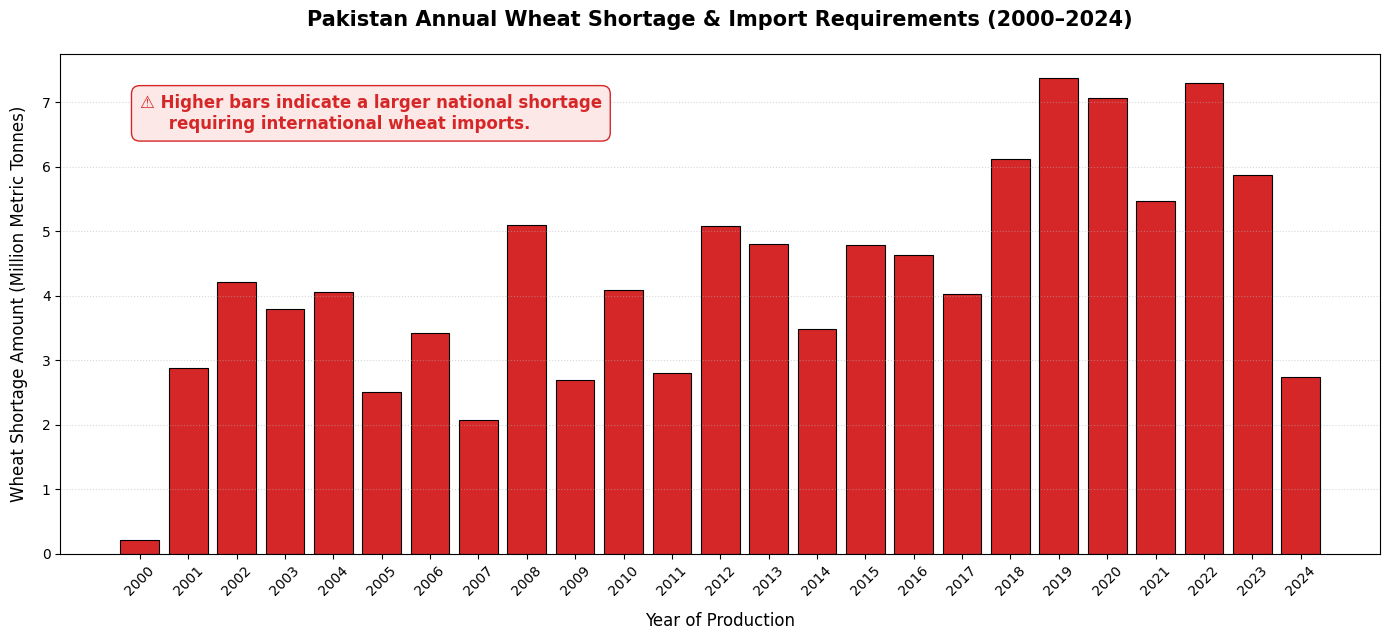

In [8]:

plt.figure(figsize=(14, 6.5))

# Convert negative deficit into positive 'Shortage Quantity' for easier reading
# If it's a deficit (negative), we flip it to positive. If it's a surplus, it becomes 0 or negative.
shortage_tonnes = final_df['Deficit_Surplus_tonnes'] * -1

# Plotting the chart (Only showing years where there was a shortage)
plt.bar(final_df['Year'], shortage_tonnes / 1e6, color='#d62728', edgecolor='black', linewidth=0.8)

# Formatting chart layout
plt.title('Pakistan Annual Wheat Shortage & Import Requirements (2000–2024)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Year of Production', fontsize=12, labelpad=10)
plt.ylabel('Wheat Shortage Amount (Million Metric Tonnes)', fontsize=12, labelpad=10)
plt.xticks(final_df['Year'], rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Adding a clear non-technical explanation label
plt.text(final_df['Year'].min(), plt.ylim()[1]*0.85, 
         '⚠️ Higher bars indicate a larger national shortage\n     requiring international wheat imports.', 
         color='#d62728', fontweight='bold', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.5", fc="#fce8e6", ec="#d62728", lw=1))

plt.tight_layout()
plt.show()

## STEP 7: INTERACTIVE DATA STORYTELLING DASHBOARD (NON-TECHNICAL PREVENTATION)
#### GRAPH 1: THE STRATEGIC 2030 YIELD GOAL (UPWARD RECOVERY TARGET)


Text(0.5, 3692.0, '🎯 Policy Action Required:\n\nMust increase crop yield by +824.00 kg/ha\nThis requires a net efficiency growth of +25.9%')

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


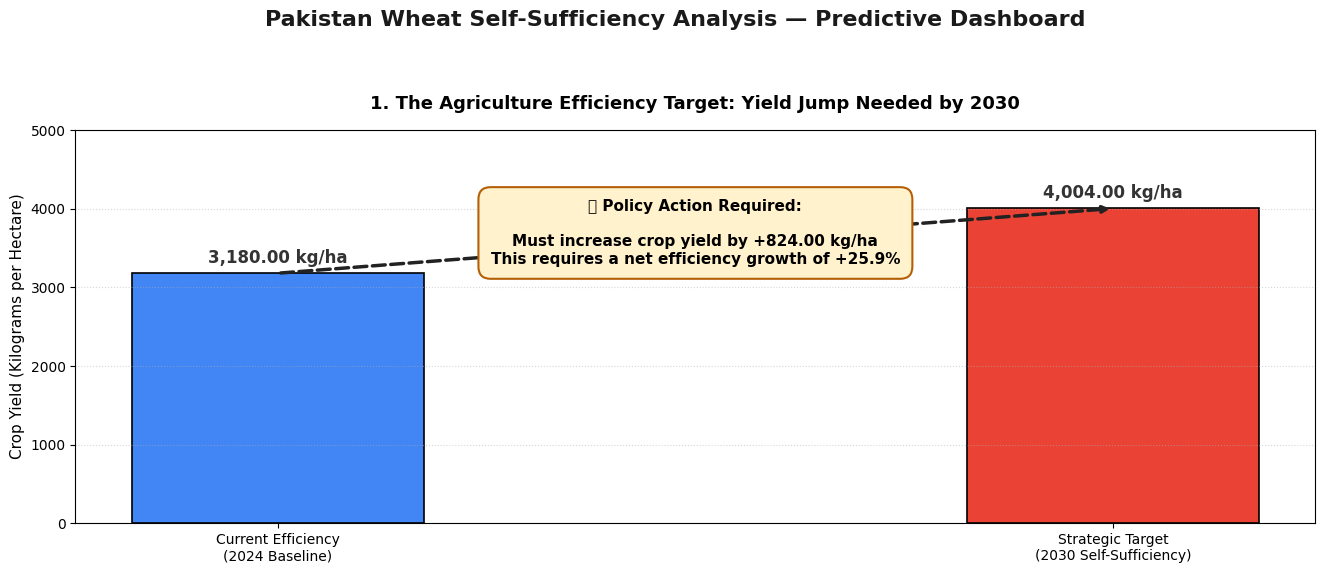

In [9]:

# Create a master 2-panel dashboard layout
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Pakistan Wheat Self-Sufficiency Analysis — Predictive Dashboard", 
             fontsize=16, fontweight='bold', y=0.98, color='#1a1a1a')

# Grid setup: 2 rows, 1 column for clean vertical stacking
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])

# Yield benchmarks from your Step 6 calculations
# (Adjust these numbers if your exact ML results vary slightly)
latest_yield_2024 = 3180.00   # Baseline yield in kg/ha
required_yield_2030 = 4004.00 # Target required yield in kg/ha
yield_gap = required_yield_2030 - latest_yield_2024
percentage_growth = (yield_gap / latest_yield_2024) * 100

categories = ['Current Efficiency\n(2024 Baseline)', 'Strategic Target\n(2030 Self-Sufficiency)']
values = [latest_yield_2024, required_yield_2030]

# Plotting the target bars
bars = ax1.bar(categories, values, color=['#4285F4', '#EA4335'], width=0.35, edgecolor='black', linewidth=1.2)

# Add clear value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, height + 80, f"{height:,.2f} kg/ha", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')

# Styling Graph 1
ax1.set_title('1. The Agriculture Efficiency Target: Yield Jump Needed by 2030', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Crop Yield (Kilograms per Hectare)', fontsize=11)
ax1.set_ylim(0, required_yield_2030 + 1000)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# Draw an arrow showing the gap direction
ax1.annotate('', xy=(1, required_yield_2030), xytext=(0, latest_yield_2024),
             arrowprops=dict(arrowstyle="->", color='#222222', lw=2.5, ls='--'))

# Non-technical explanation callout box
ax1.text(0.5, (latest_yield_2024 + required_yield_2030)/2 + 100, 
         f"🎯 Policy Action Required:\n\nMust increase crop yield by +{yield_gap:,.2f} kg/ha\n"
         f"This requires a net efficiency growth of +{percentage_growth:.1f}%", 
         ha='center', va='center', color='black', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.8", fc="#fff2cc", ec="#b45f06", lw=1.5))


